# Phase 2: GCN and GAT Baselines
Trains GCN and GAT on Twitter15 and Twitter16 with 5 random seeds on a fixed 60/20/20 stratified split.
Reports mean ± std macro-F1 and accuracy on the test set.

In [10]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import torch

from data.dataset import CascadeDataset
from models.gcn import GCNClassifier
from models.gat import GATClassifier
from training.trainer import run_experiment

DATA_ROOT = "../Twitter15_16_dataset-main"
DEVICE = "cuda"  # MPS kernel overhead is slower than CPU for many small graphs
print(f"Device: {DEVICE}")

Device: cuda


In [11]:
ds15 = CascadeDataset(root=DATA_ROOT, name="twitter15")
ds16 = CascadeDataset(root=DATA_ROOT, name="twitter16")
IN_CHANNELS = ds15[0].x.shape[1]  # 30
print(f"Twitter15: {len(ds15)} graphs   Twitter16: {len(ds16)} graphs   in_channels: {IN_CHANNELS}")

Twitter15: 1490 graphs   Twitter16: 818 graphs   in_channels: 30


In [12]:
SEEDS = [0, 1, 2, 3, 4]
EPOCHS = 200

GCN_KWARGS = dict(in_channels=IN_CHANNELS, hidden_channels=128, num_layers=3, dropout=0.1)
GAT_KWARGS = dict(in_channels=IN_CHANNELS, hidden_channels=128, num_layers=3, heads=4, dropout=0.1)

In [13]:
print("=" * 50)
print("GCN — Twitter15")
print("=" * 50)
gcn15 = run_experiment(GCNClassifier, GCN_KWARGS, ds15, SEEDS, epochs=EPOCHS, device=DEVICE)

GCN — Twitter15
  seed=0 epoch= 20  train_loss=1.0971  val_f1=0.4260  best=0.4392
  seed=0 epoch= 40  train_loss=1.0397  val_f1=0.4431  best=0.4471
  seed=0 epoch= 60  train_loss=1.0109  val_f1=0.4244  best=0.4639
  seed=0 epoch= 80  train_loss=0.9606  val_f1=0.4207  best=0.4639
  seed=0 epoch=100  train_loss=0.9692  val_f1=0.4209  best=0.4639
  seed=0 epoch=120  train_loss=0.9496  val_f1=0.4161  best=0.4639
  seed=0 epoch=140  train_loss=0.9558  val_f1=0.4260  best=0.4639
  seed=0 epoch=160  train_loss=0.9561  val_f1=0.4200  best=0.4639
  seed=0 epoch=180  train_loss=0.9692  val_f1=0.4241  best=0.4639
  seed=0 epoch=200  train_loss=0.9553  val_f1=0.4237  best=0.4639
  seed=0  best_val_f1=0.4639  test_acc=0.4564  test_f1=0.4462
  seed=1 epoch= 20  train_loss=1.0584  val_f1=0.4350  best=0.4361
  seed=1 epoch= 40  train_loss=1.0079  val_f1=0.3952  best=0.4533
  seed=1 epoch= 60  train_loss=0.9496  val_f1=0.4252  best=0.4533
  seed=1 epoch= 80  train_loss=0.9363  val_f1=0.4174  best=0.453

KeyboardInterrupt: 

In [ ]:
print("=" * 50)
print("GAT — Twitter15")
print("=" * 50)
gat15 = run_experiment(GATClassifier, GAT_KWARGS, ds15, SEEDS, epochs=EPOCHS, device=DEVICE)

GAT — Twitter15
  seed=0 epoch= 20  train_loss=1.0752  val_f1=0.3996  best=0.4277
  seed=0 epoch= 40  train_loss=0.6518  val_f1=0.3878  best=0.4372
  seed=0 epoch= 60  train_loss=0.3044  val_f1=0.3862  best=0.4372
  seed=0 epoch= 80  train_loss=0.2051  val_f1=0.3708  best=0.4372
  seed=0 epoch=100  train_loss=0.1968  val_f1=0.3672  best=0.4372
  seed=0 epoch=120  train_loss=0.1670  val_f1=0.3766  best=0.4372
  seed=0 epoch=140  train_loss=0.1793  val_f1=0.3775  best=0.4372
  seed=0 epoch=160  train_loss=0.1720  val_f1=0.3710  best=0.4372
  seed=0 epoch=180  train_loss=0.1345  val_f1=0.3771  best=0.4372
  seed=0 epoch=200  train_loss=0.1611  val_f1=0.3734  best=0.4372
  seed=0  best_val_f1=0.4372  test_acc=0.4396  test_f1=0.4394
  seed=1 epoch= 20  train_loss=0.9650  val_f1=0.3709  best=0.4228
  seed=1 epoch= 40  train_loss=0.6688  val_f1=0.3629  best=0.4228
  seed=1 epoch= 60  train_loss=0.4070  val_f1=0.3633  best=0.4228
  seed=1 epoch= 80  train_loss=0.3373  val_f1=0.3677  best=0.422

In [ ]:
print("=" * 50)
print("GCN — Twitter16")
print("=" * 50)
gcn16 = run_experiment(GCNClassifier, GCN_KWARGS, ds16, SEEDS, epochs=EPOCHS, device=DEVICE)

GCN — Twitter16
  seed=0 epoch= 20  train_loss=1.1034  val_f1=0.4396  best=0.4711
  seed=0 epoch= 40  train_loss=1.0314  val_f1=0.4592  best=0.4993
  seed=0 epoch= 60  train_loss=0.9827  val_f1=0.4624  best=0.4993
  seed=0 epoch= 80  train_loss=0.9467  val_f1=0.4850  best=0.4993
  seed=0 epoch=100  train_loss=0.9415  val_f1=0.4596  best=0.4993
  seed=0 epoch=120  train_loss=0.9299  val_f1=0.4676  best=0.4993
  seed=0 epoch=140  train_loss=0.9520  val_f1=0.4620  best=0.4993
  seed=0 epoch=160  train_loss=0.9416  val_f1=0.4804  best=0.4993
  seed=0 epoch=180  train_loss=0.9549  val_f1=0.4581  best=0.4993
  seed=0 epoch=200  train_loss=0.9463  val_f1=0.4752  best=0.4993
  seed=0  best_val_f1=0.4993  test_acc=0.4085  test_f1=0.3716
  seed=1 epoch= 20  train_loss=1.0908  val_f1=0.4328  best=0.4529
  seed=1 epoch= 40  train_loss=1.0268  val_f1=0.4255  best=0.4673
  seed=1 epoch= 60  train_loss=0.9570  val_f1=0.4268  best=0.4974
  seed=1 epoch= 80  train_loss=0.9033  val_f1=0.4322  best=0.500

In [ ]:
print("=" * 50)
print("GAT — Twitter16")
print("=" * 50)
gat16 = run_experiment(GATClassifier, GAT_KWARGS, ds16, SEEDS, epochs=EPOCHS, device=DEVICE)

GAT — Twitter16
  seed=0 epoch= 20  train_loss=0.9888  val_f1=0.4154  best=0.4864
  seed=0 epoch= 40  train_loss=0.6097  val_f1=0.4540  best=0.5019
  seed=0 epoch= 60  train_loss=0.3120  val_f1=0.4321  best=0.5019
  seed=0 epoch= 80  train_loss=0.2149  val_f1=0.4230  best=0.5019
  seed=0 epoch=100  train_loss=0.1960  val_f1=0.4122  best=0.5019
  seed=0 epoch=120  train_loss=0.1631  val_f1=0.4120  best=0.5019
  seed=0 epoch=140  train_loss=0.1434  val_f1=0.4123  best=0.5019
  seed=0 epoch=160  train_loss=0.1652  val_f1=0.3999  best=0.5019
  seed=0 epoch=180  train_loss=0.1561  val_f1=0.4117  best=0.5019
  seed=0 epoch=200  train_loss=0.1652  val_f1=0.3997  best=0.5019
  seed=0  best_val_f1=0.5019  test_acc=0.3598  test_f1=0.3710
  seed=1 epoch= 20  train_loss=0.8874  val_f1=0.4091  best=0.4541
  seed=1 epoch= 40  train_loss=0.5263  val_f1=0.4325  best=0.4541
  seed=1 epoch= 60  train_loss=0.3235  val_f1=0.3980  best=0.4541
  seed=1 epoch= 80  train_loss=0.3335  val_f1=0.3881  best=0.454

In [ ]:
print("\n" + "=" * 62)
print(f"{'Model':<10} {'Dataset':<12} {'Acc mean±std':>16} {'Macro-F1 mean±std':>20}")
print("-" * 62)

rows = [
    ("GCN",  "Twitter15", gcn15),
    ("GAT",  "Twitter15", gat15),
    ("GCN",  "Twitter16", gcn16),
    ("GAT",  "Twitter16", gat16),
]
for model, dataset, res in rows:
    acc  = f"{res['test_acc_mean']:.3f} ± {res['test_acc_std']:.3f}"
    f1   = f"{res['test_f1_mean']:.3f} ± {res['test_f1_std']:.3f}"
    print(f"{model:<10} {dataset:<12} {acc:>16} {f1:>20}")

print("=" * 62)
print("(5 seeds, 60/20/20 stratified split, best val-F1 checkpoint)")


Model      Dataset          Acc mean±std    Macro-F1 mean±std
--------------------------------------------------------------
GCN        Twitter15       0.446 ± 0.032        0.433 ± 0.029
GAT        Twitter15       0.454 ± 0.027        0.427 ± 0.042
GCN        Twitter16       0.423 ± 0.039        0.402 ± 0.038
GAT        Twitter16       0.413 ± 0.043        0.403 ± 0.045
(5 seeds, 60/20/20 stratified split, best val-F1 checkpoint)


| Model  | Dataset    | Acc mean ± std | Macro-F1 mean ± std |
|--------|------------|----------------|---------------------|
| GCN    | Twitter15  | 0.446 ± 0.032  |  0.433 ± 0.029      |
| GAT    | Twitter15  | 0.454 ± 0.027  |  0.427 ± 0.042      |
| GCN    | Twitter16  | 0.423 ± 0.039  |  0.402 ± 0.038      |
| GAT    | Twitter16  | 0.413 ± 0.043  |  0.403 ± 0.045      |

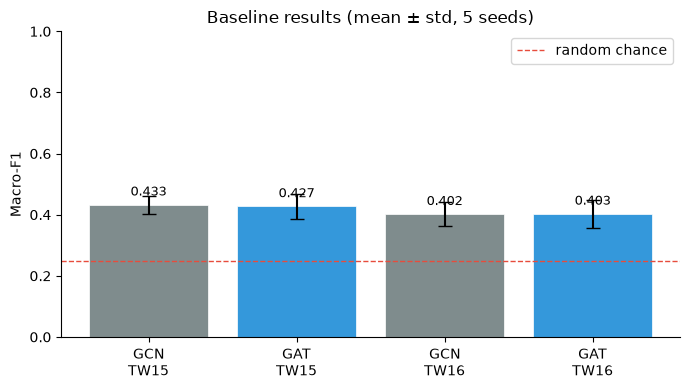

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels  = ["GCN\nTW15", "GAT\nTW15", "GCN\nTW16", "GAT\nTW16"]
means   = [r["test_f1_mean"] for _, _, r in rows]
stds    = [r["test_f1_std"]  for _, _, r in rows]
colors  = ["#7f8c8d", "#3498db", "#7f8c8d", "#3498db"]

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(labels))
bars = ax.bar(x, means, yerr=stds, capsize=5, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(0.25, color="#e74c3c", linestyle="--", linewidth=1, label="random chance")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel("Macro-F1")
ax.set_title("Baseline results (mean ± std, 5 seeds)")
ax.set_ylim(0, 1.0)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{m:.3f}",
            ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("../data/baseline_results.png", dpi=120, bbox_inches="tight")
plt.show()